In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import socket

In [56]:
lake = 'zug'
horizontal_resolution = 100
base_folder = rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025'

In [57]:
bin_file_path = os.path.join(base_folder, 'binary_data', "bathy.bin")

In [58]:
with open(bin_file_path, 'rb') as fid:
    binary_data = np.fromfile(fid, dtype='>f8')

In [59]:
Nx=0
Ny=0
if lake == 'lucerne':
    Nx = 288
    Ny = 180
elif lake == 'geneva':
    Nx = 660
    Ny = 245
elif lake == 'neuchatel':
    Nx = 390
    Ny = 96
elif lake == 'zug':
    Nx = 50
    Ny = 140

print(f"Lake: {lake}, Nx: {Nx}, Ny: {Ny}")

Lake: zug, Nx: 50, Ny: 140


In [62]:
bathy_array = np.reshape(binary_data, (int(Ny),int(Nx)))
bathy_array = np.asarray(bathy_array, dtype=np.float64)
bathy_array = bathy_array.astype(np.float64, copy=False)

bathy_array[bathy_array>-10] = 2

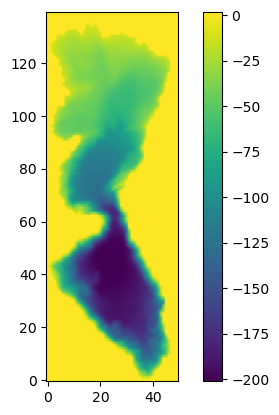

In [63]:
plt.imshow(bathy_array, origin='lower')
plt.colorbar()

In [64]:
from scipy.ndimage import distance_transform_edt

water = bathy_array <= 0

# radius of largest circle
radius = distance_transform_edt(water, sampling=(horizontal_resolution, horizontal_resolution))

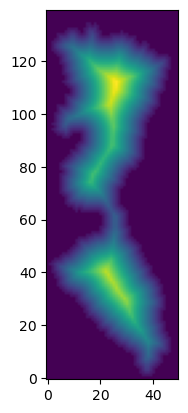

In [65]:
plt.imshow(radius, origin='lower')

In [66]:
coeff_gap=1

In [67]:
import numpy as np
from scipy.ndimage import distance_transform_edt
from numba import njit, prange


# ============================================================
# Compute ray paths using DDA
# ============================================================

def generate_ray_offsets(angle, max_distance, dx, dy):
    """
    Generate grid offsets crossed by a ray at a given angle.
    """

    ca = np.cos(angle)
    sa = np.sin(angle)

    # Normalize direction
    length = np.sqrt(ca**2 + sa**2)
    ca /= length
    sa /= length

    # maximum number of steps
    nsteps = int(max_distance / min(dx, dy)) + 2

    offsets = []
    distances = []

    x = 0.0
    y = 0.0

    old_i = 0
    old_j = 0

    for k in range(nsteps):

        x += ca * min(dx, dy)
        y += sa * min(dx, dy)

        j = int(np.floor(x / dx + 0.5))
        i = int(np.floor(y / dy + 0.5))

        if i != old_i or j != old_j:

            offsets.append((i, j))
            distances.append(np.sqrt((i*dy)**2 + (j*dx)**2))

            old_i = i
            old_j = j

    return (
        np.array(offsets, dtype=np.int32),
        np.array(distances, dtype=np.float64)
    )


# ============================================================
# Create all rays
# ============================================================

def create_rays(dAlpha, max_distance, dx, dy):

    angles = np.deg2rad(
        np.arange(0, 360, dAlpha)
    )

    ray_offsets = []
    ray_distances = []

    for a in angles:

        off, dist = generate_ray_offsets(
            a,
            max_distance,
            dx,
            dy
        )

        ray_offsets.append(off)
        ray_distances.append(dist)

    return ray_offsets, ray_distances



# ============================================================
# Fast computation of radial gaps
# ============================================================

@njit(parallel=True)
def compute_gap_sum(
        bathy,
        radius,
        ray_offsets,
        ray_distances):

    ny, nx = bathy.shape

    result = np.zeros((ny, nx))
    perc_gaps_below_threshold = np.zeros((ny, nx))

    n_angles = len(ray_offsets)


    for i in prange(ny):

        for j in range(nx):

            # skip land
            if bathy[i,j] > 0:
                result[i,j] = np.nan
                continue


            r0 = radius[i,j]

            total = 0.0
            total_gaps_below_threshold = 0
            for a in range(n_angles):

                offsets = ray_offsets[a]
                distances = ray_distances[a]


                # start after the inscribed circle
                start = 0

                while start < len(distances):

                    if distances[start] >= r0:
                        break

                    start += 1


                # march outward until land

                for k in range(start, len(distances)):

                    ii = i + offsets[k,0]
                    jj = j + offsets[k,1]


                    # outside domain
                    if (
                        ii < 0 or ii >= ny or
                        jj < 0 or jj >= nx
                    ):
                        break


                    if bathy[ii,jj] > 0:
                        if distances[k] - r0 < r0*coeff_gap:
                            total_gaps_below_threshold += 1
                        total += distances[k] - r0

                        break


            result[i,j] = total
            perc_gaps_below_threshold[i,j] = 100*total_gaps_below_threshold/n_angles


    return result, perc_gaps_below_threshold



# ============================================================
# Main function
# ============================================================

def bathymetry_clearance(
        bathy,
        dx,
        dy,
        dAlpha=5):

    """
    Parameters
    ----------
    bathy : 2D numpy array
        bathymetry values
        positive = land
        negative = water

    dx,dy : float
        grid spacing in meters

    dAlpha : float
        angular resolution in degrees


    Returns
    -------
    radius :
        largest empty circle radius

    gap_sum :
        sum of radial gaps over all angles
    """


    water = bathy <= 0


    # Largest circle radius

    radius = distance_transform_edt(
        water,
        sampling=(dy,dx)
    )


    # Maximum ray length:
    # diagonal of the domain

    ny,nx = bathy.shape

    max_distance = np.sqrt(
        (nx*dx)**2 +
        (ny*dy)**2
    )


    # Precompute rays

    ray_offsets, ray_distances = create_rays(
        dAlpha,
        max_distance,
        dx,
        dy
    )


    # Convert lists to numba-friendly arrays

    max_len = max(
        len(x) for x in ray_distances
    )

    n_angles = len(ray_offsets)


    offsets_array = np.zeros(
        (n_angles,max_len,2),
        dtype=np.int32
    )

    distances_array = np.zeros(
        (n_angles,max_len)
    )


    for a in range(n_angles):

        n = len(ray_distances[a])

        offsets_array[a,:n,:] = ray_offsets[a]

        distances_array[a,:n] = ray_distances[a]


    gap_sum, perc_gaps_below_threshold = compute_gap_sum(
        bathy,
        radius,
        offsets_array,
        distances_array
    )


    return radius, gap_sum, perc_gaps_below_threshold

In [68]:
radius, gap, perc_gaps_below_threshold = bathymetry_clearance(
    bathy_array,
    horizontal_resolution,
    horizontal_resolution,
    dAlpha=5
)

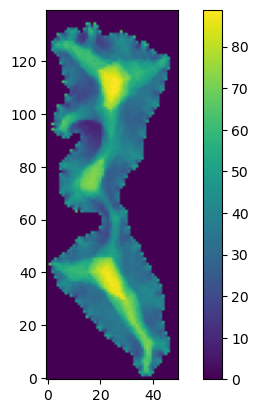

In [69]:
plt.imshow(perc_gaps_below_threshold, origin='lower')
plt.colorbar()

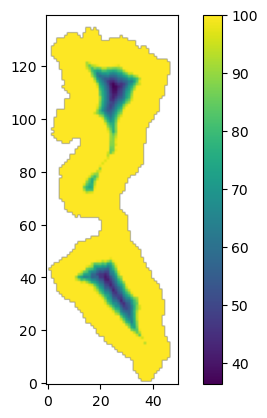

In [70]:
plt.imshow(gap/radius, origin='lower', vmax=100)
plt.colorbar()

In [71]:
threshold = (gap/radius) < 100

Number of circles: 529


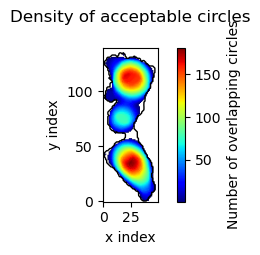

In [72]:
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------------------------------
# Create threshold mask
# -------------------------------------------------------

ratio = np.full_like(gap, np.inf, dtype=float)

valid = radius > 0
ratio[valid] = gap[valid] / radius[valid]

threshold = perc_gaps_below_threshold>60 #(ratio < 100)

# keep only water points
threshold &= (bathy_array <= 0)


# -------------------------------------------------------
# Selected circle centers
# -------------------------------------------------------

iy, ix = np.where(threshold)

print("Number of circles:", len(ix))


# -------------------------------------------------------
# Compute circle density map
# -------------------------------------------------------

ny, nx = bathy_array.shape

density = np.zeros((ny, nx), dtype=np.float32)


for y, x in zip(iy, ix):

    r = radius[y, x]/horizontal_resolution

    if r <= 0:
        continue

    # Bounding box of the circle
    xmin = max(0, int(x - r))
    xmax = min(nx - 1, int(x + r))

    ymin = max(0, int(y - r))
    ymax = min(ny - 1, int(y + r))


    # Coordinates inside the bounding box
    yy, xx = np.indices(
        (ymax - ymin + 1,
         xmax - xmin + 1)
    )

    xx += xmin
    yy += ymin


    # Mask points inside the circle
    inside = (
        (xx - x)**2 +
        (yy - y)**2
        <= r**2
    )


    density[
        ymin:ymax+1,
        xmin:xmax+1
    ][inside] += 1



# -------------------------------------------------------
# Plot density map
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 2))

density[density==0] = np.nan
im = ax.imshow(
    density,
    origin="lower",
    cmap="jet"
)


# Shoreline
ax.contour(
    bathy_array,
    levels=[0],
    colors="black",
    linewidths=1
)


plt.colorbar(
    im,
    ax=ax,
    label="Number of overlapping circles"
)


ax.set_aspect("equal")

ax.set_title(
    "Density of acceptable circles\n"
)

ax.set_xlabel("x index")
ax.set_ylabel("y index")

plt.show()

In [73]:
np.nansum(density) / len(bathy_array[bathy_array< 0])

np.float32(67.929436)

In [74]:
len(bathy_array[bathy_array< 0])

3727

In [75]:
range(0,10)[-1]

9

# Get fetch per wind direction for each cell

In [68]:
import numpy as np
from numba import njit, prange


@njit
def distance_one_direction(bathy, i0, j0, di, dj, max_steps):
    """
    Distance from a point to the first shore along a direction.
    """

    ny, nx = bathy.shape

    for k in range(1, max_steps):

        i = i0 + int(round(k * di))
        j = j0 + int(round(k * dj))

        if i < 0 or i >= ny or j < 0 or j >= nx:
            return np.nan

        if bathy[i, j] > 0:
            return k

    return np.nan



@njit(parallel=True)
def shore_to_shore_distance(
        bathy,
        angle,
        max_steps):

    """
    Distance between opposite shores along angle.
    """

    ny, nx = bathy.shape

    result = np.full(
        (ny, nx),
        np.nan
    )

    ca = np.cos(angle)
    sa = np.sin(angle)


    for i in prange(ny):

        for j in range(nx):

            # ignore land
            if bathy[i,j] > 0:
                continue


            d1 = distance_one_direction(
                bathy,
                i,
                j,
                sa,
                ca,
                max_steps
            )

            d2 = distance_one_direction(
                bathy,
                i,
                j,
                -sa,
                -ca,
                max_steps
            )


            if not np.isnan(d1) and not np.isnan(d2):
                result[i,j] = d1 + d2


    return result

In [83]:
import numpy as np
import xarray as xr


# -------------------------------------------------------
# Define angular discretization
# -------------------------------------------------------

dAlpha = 5

angle_deg = np.arange(
    0,
    180,
    dAlpha
)

angle_rad = np.deg2rad(angle_deg)

n_angles = len(angle_deg)


# -------------------------------------------------------
# Compute directional distances
# -------------------------------------------------------

shore_widths = np.zeros(
    (
        n_angles,
        *bathy_array.shape
    ),
    dtype=np.float32
)


for k, alpha in enumerate(angle_rad):

    print(f"{angle_deg[k]} degrees")

    shore_widths[k] = shore_to_shore_distance(
        bathy_array,
        alpha,
        max_steps=2000
    )


# -------------------------------------------------------
# Store as xarray
# -------------------------------------------------------

ds_width = xr.DataArray(
    shore_widths*horizontal_resolution,
    dims=("angle", "y", "x"),
    coords={
        "angle": angle_deg,
    },
    name="fetch"
)

ds_width.attrs["description"] = (
    "Distance between opposite shorelines "
    "along the specified angle"
)

ds_width.attrs["angle_resolution"] = (
    f"{dAlpha} degrees"
)


print(ds_width)

0 degrees
5 degrees
10 degrees
15 degrees
20 degrees
25 degrees
30 degrees
35 degrees
40 degrees
45 degrees
50 degrees
55 degrees
60 degrees
65 degrees
70 degrees
75 degrees
80 degrees
85 degrees
90 degrees
95 degrees
100 degrees
105 degrees
110 degrees
115 degrees
120 degrees
125 degrees
130 degrees
135 degrees
140 degrees
145 degrees
150 degrees
155 degrees
160 degrees
165 degrees
170 degrees
175 degrees
<xarray.DataArray 'fetch' (angle: 36, y: 140, x: 50)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
   

In [84]:
ds_width.to_netcdf(os.path.join(rf"/storage/alplakes_test/{lake}_100m_2025/seiche_analysis/fetch_per_angle.nc"))

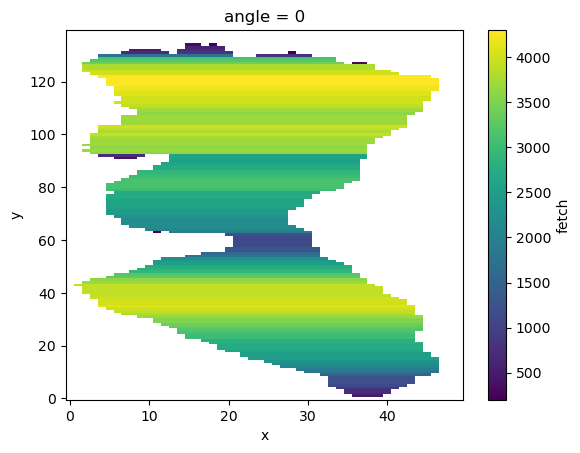

In [85]:
ds_width.sel(angle=0).plot()